In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv("netflix_titles.csv")
data.head()

# **Data Cleaning**

In [16]:
data.shape

(8807, 12)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [18]:
data.duplicated().sum()

np.int64(0)

In [45]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [30]:
data["director"].fillna("Unknown" ,inplace = True)

In [31]:
data["cast"].fillna("Unknown" ,inplace = True)

In [33]:
data["country"].fillna(data["country"].mode()[0] ,inplace = True)

In [44]:
data.dropna(subset = ["date_added"], inplace = True)

In [42]:
data["rating"].fillna(data["rating"].mode()[0], inplace = True)

In [37]:
data.dropna(subset = ["duration"], inplace = True)

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8804 non-null   object
 1   type          8804 non-null   object
 2   title         8804 non-null   object
 3   director      8804 non-null   object
 4   cast          8804 non-null   object
 5   country       8804 non-null   object
 6   date_added    8794 non-null   object
 7   release_year  8804 non-null   int64 
 8   rating        8800 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8804 non-null   object
 11  description   8804 non-null   object
dtypes: int64(1), object(11)
memory usage: 894.2+ KB


# **EDA**

In [46]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<Figure size 600x400 with 0 Axes>

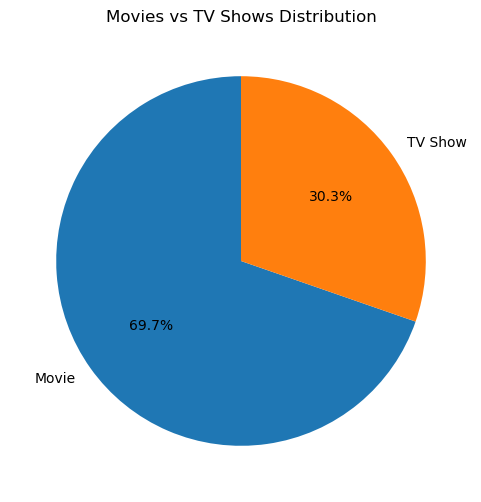

In [69]:
# Number of Movies vs TV Shows

content_type = data['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(content_type,
        labels=content_type.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Movies vs TV Shows Distribution")
plt.show()

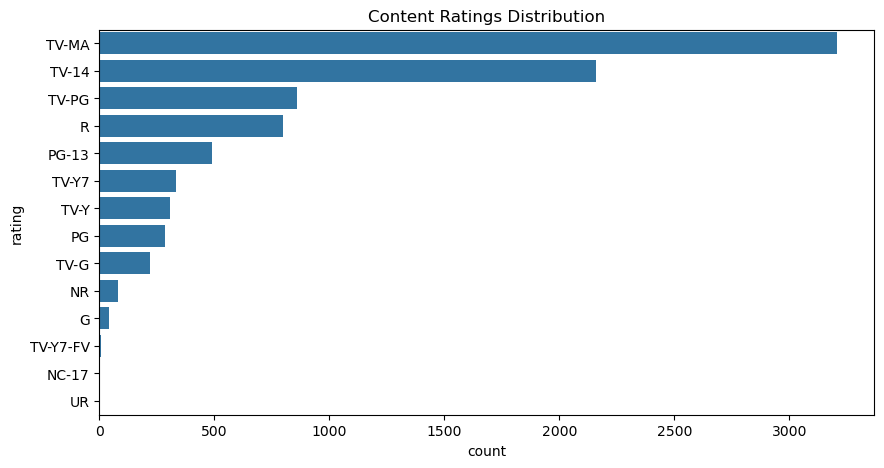

In [54]:
# Most Common Ratings

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    y='rating',
    order=data['rating'].value_counts().index
)

plt.title("Content Ratings Distribution")

plt.show()

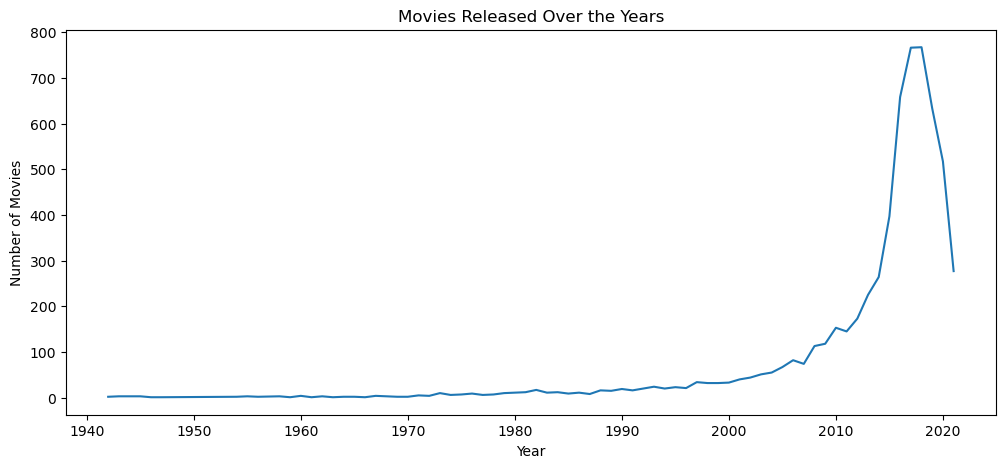

In [61]:
# Movies Released Per Year

movies = data[data['type'] == 'Movie']

movie_year = (
    movies['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(movie_year.index,
         movie_year.values)

plt.title("Movies Released Over the Years")

plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

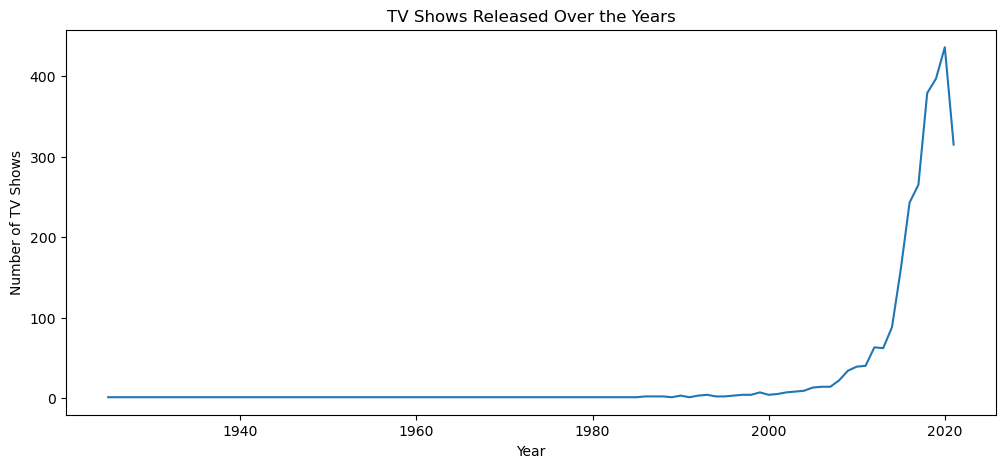

In [62]:
# TV Shows Released Per Year

tv = data[data['type'] == 'TV Show']

tv_year = (
    tv['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

plt.plot(tv_year.index,
         tv_year.values)

plt.title("TV Shows Released Over the Years")

plt.xlabel("Year")
plt.ylabel("Number of TV Shows")

plt.show()

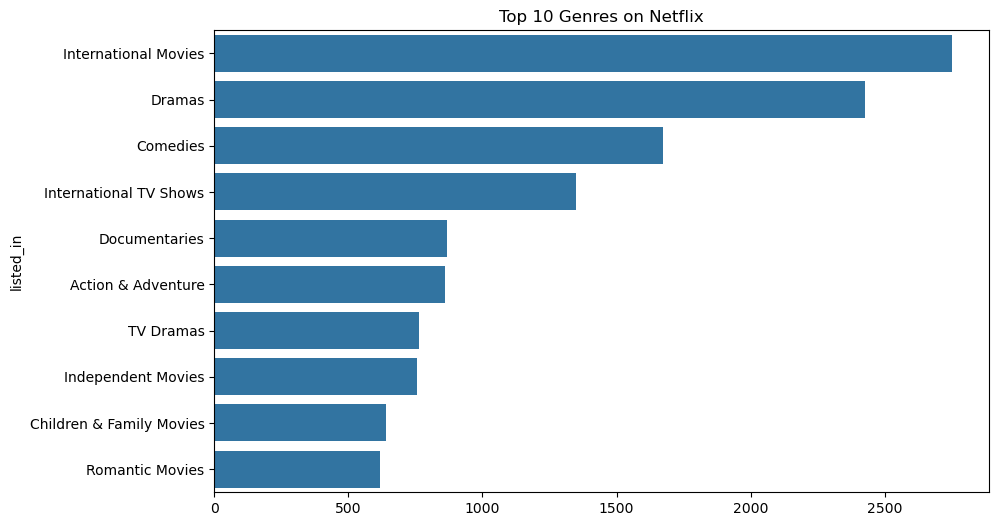

In [64]:
# Top Genres

genre = (
    data['listed_in']
    .str.split(',')
    .explode()
    .str.strip()
)

top_genre = genre.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genre.values,
    y=top_genre.index
)

plt.title("Top 10 Genres on Netflix")

plt.show()

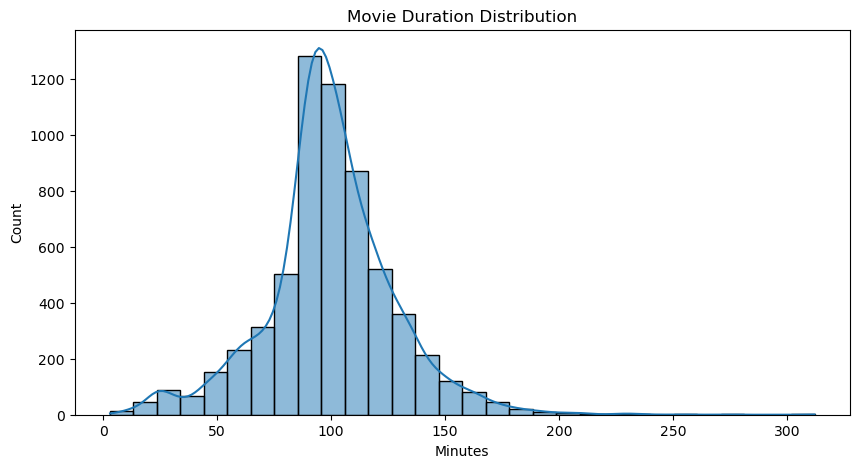

In [65]:
# Duration Analysis

movie_duration = data[data['type']=='Movie'].copy()

movie_duration['minutes'] = (
    movie_duration['duration']
    .str.replace(' min','')
    .astype(int)
)

plt.figure(figsize=(10,5))

sns.histplot(
    movie_duration['minutes'],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")

plt.xlabel("Minutes")

plt.show()

In [66]:
# Longest Movie

movie_duration.sort_values(
    by='minutes',
    ascending=False
)[['title','minutes']].head(10)



,title,minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233
2488,Raya and Sakina,230
166,Once Upon a Time in America,229
7932,Sangam,228
1019,Lagaan,224
4573,Jodhaa Akbar,214


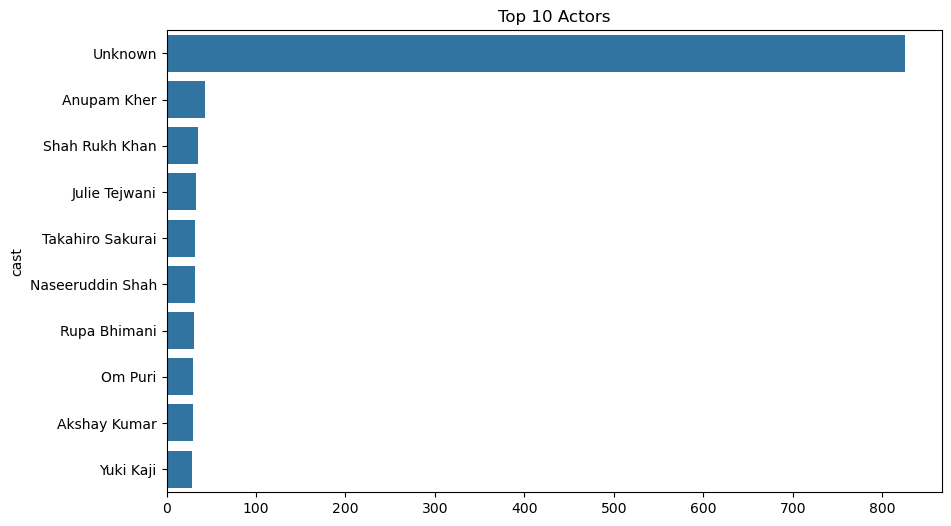

In [68]:
# Most Frequent Actors

cast = (
    data['cast']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

top_actor = cast.value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_actor.values,
    y=top_actor.index
)

plt.title("Top 10 Actors")

plt.show()

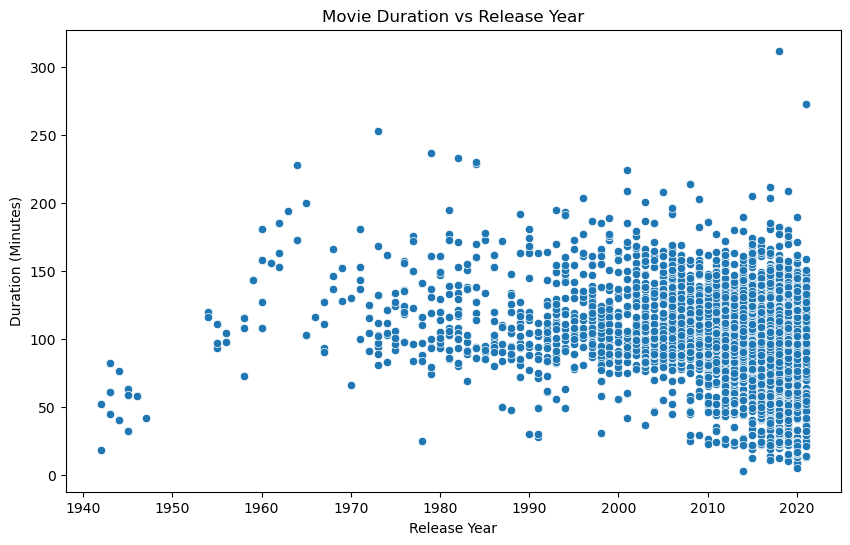

In [71]:
# Release Year vs Movie Duration

movie_df = data[data['type'] == 'Movie'].copy()

movie_df['duration_min'] = (
    movie_df['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=movie_df,
    x='release_year',
    y='duration_min'
)

plt.title("Movie Duration vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.show()

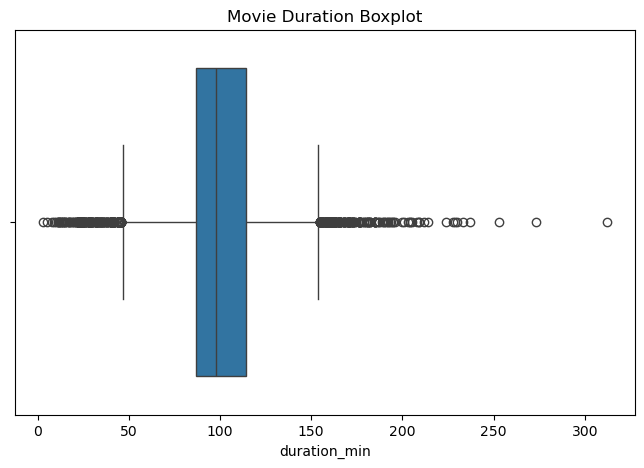

In [72]:
# Movie Duration

plt.figure(figsize=(8,5))

sns.boxplot(
    x=movie_df['duration_min']
)

plt.title("Movie Duration Boxplot")

plt.show()